# Visualize Hate / Non-Hate Vision Dataset In 2D / 3D

This notebook projects the video dataset into 2D and 3D spaces using visual embeddings from sampled frames.

It helps inspect:
- class separability
- outliers
- train/val/test distribution drift
- suspicious clusters or label noise

Input:
- `E:/m-hvc/datasets/old-dataset/video_df.csv`
- `E:/m-hvc/datasets/old-dataset/frames_unique/{source_video_id}/*.jpg`

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
import timm

warnings.filterwarnings("ignore", category=UserWarning)


C:\Users\Rasheek\.conda\envs\fyp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


PROJECT_ROOT = Path(r"E:/m-hvc")
DATASET_DIR = PROJECT_ROOT / "datasets" / "old-dataset"
MANIFEST_PATH = DATASET_DIR / "video_df.csv"
FRAMES_ROOT = DATASET_DIR / "frames_unique"

NOTEBOOK_DIR = PROJECT_ROOT / "multimodal-hvc" / "hate_non_hate_vision_classification"
REPORT_DIR = NOTEBOOK_DIR / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = {
    "seed": 42,
    "image_size": 224,
    "num_frames_for_embedding": 8,
    "batch_size": 16,
    "num_workers": 0,
    "max_videos": None,
    "backbone": "convnext_base.fb_in22k_ft_in1k",
    "fallback_backbones": ["tf_efficientnetv2_s.in21k_ft_in1k", "efficientnet_b3.ra2_in1k", "resnet50.a1_in1k"],
    "val_size": 0.15,
    "test_size": 0.15,
    "tsne_perplexity": 35,
}

set_seed(CFG["seed"])
print(f"device: {DEVICE}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")


device: cuda
gpu: NVIDIA GeForce RTX 4070


## Load Manifest And Build Splits

In [3]:
def numeric_frame_key(path: Path):
    stem = path.stem.split("_", 1)[0]
    return (0, int(stem)) if stem.isdigit() else (1, path.stem)


def list_frame_paths(frame_dir):
    frame_dir = Path(frame_dir)
    if not frame_dir.exists():
        return []
    paths = [path for path in frame_dir.iterdir() if path.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    return sorted(paths, key=numeric_frame_key)


manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df["source_video_id"] = manifest_df["source_video_id"].astype(str)
manifest_df["label"] = manifest_df["label"].astype(int)
manifest_df["label_name"] = manifest_df["label"].map({0: "non_hate", 1: "hate"})
manifest_df["frame_dir"] = manifest_df.get(
    "frame_dir",
    manifest_df["source_video_id"].map(lambda value: str(FRAMES_ROOT / str(value))),
)
manifest_df["frame_dir"] = manifest_df.apply(
    lambda row: str(FRAMES_ROOT / str(row.source_video_id)) if pd.isna(row.frame_dir) else str(row.frame_dir),
    axis=1,
)
manifest_df["num_available_frames"] = manifest_df["frame_dir"].map(lambda value: len(list_frame_paths(value)))

clip_df = manifest_df[manifest_df["num_available_frames"] > 0].copy().reset_index(drop=True)
if CFG["max_videos"] is not None and len(clip_df) > int(CFG["max_videos"]):
    clip_df = clip_df.groupby("label", group_keys=False).sample(
        frac=min(1.0, int(CFG["max_videos"]) / len(clip_df)),
        random_state=CFG["seed"],
    ).reset_index(drop=True)

train_val_df, test_df = train_test_split(
    clip_df,
    test_size=CFG["test_size"],
    random_state=CFG["seed"],
    stratify=clip_df["label"],
)
relative_val_size = CFG["val_size"] / (1.0 - CFG["test_size"])
train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_size,
    random_state=CFG["seed"],
    stratify=train_val_df["label"],
)

viz_df = pd.concat(
    [train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")],
    ignore_index=True,
).reset_index(drop=True)

print(f"videos with frames: {len(viz_df):,}")
display(pd.crosstab(viz_df["split"], viz_df["label_name"]))
display(viz_df["num_available_frames"].describe().to_frame().T)


videos with frames: 3,281


label_name,hate,non_hate
split,,
test,200,293
train,933,1362
val,200,293


,count,mean,std,min,25%,50%,75%,max
num_available_frames,3281.0,46.509296,23.358774,1.0,28.0,64.0,64.0,64.0


## Embedding Dataset

In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def uniform_indices(num_items, num_frames):
    if num_items <= 1:
        return np.zeros(num_frames, dtype=np.int32)
    indices = np.linspace(0, num_items - 1, num=num_frames)
    return np.clip(np.round(indices).astype(np.int32), 0, num_items - 1)


def sample_frame_paths(frame_dir, num_frames):
    frame_paths = list_frame_paths(frame_dir)
    if not frame_paths:
        raise FileNotFoundError(f"No frames found in {frame_dir}")
    indices = uniform_indices(len(frame_paths), num_frames)
    return [frame_paths[index] for index in indices]


class EmbeddingClipTransform:
    def __init__(self, image_size=224):
        self.image_size = image_size

    def __call__(self, images):
        processed = []
        resize_size = int(self.image_size * 1.15)
        for image in images:
            image = image.convert("RGB")
            image = TF.resize(image, resize_size, interpolation=InterpolationMode.BILINEAR)
            image = TF.center_crop(image, [self.image_size, self.image_size])
            tensor = TF.to_tensor(image)
            tensor = TF.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)
            processed.append(tensor)
        return torch.stack(processed, dim=0)


class VideoEmbeddingDataset(Dataset):
    def __init__(self, frame_df, num_frames, image_size):
        self.frame_df = frame_df.reset_index(drop=True)
        self.num_frames = int(num_frames)
        self.transform = EmbeddingClipTransform(image_size=image_size)

    def __len__(self):
        return len(self.frame_df)

    def __getitem__(self, index):
        row = self.frame_df.iloc[index]
        frame_paths = sample_frame_paths(row.frame_dir, self.num_frames)
        images = []
        for frame_path in frame_paths:
            with Image.open(frame_path) as image:
                images.append(image.convert("RGB"))
        clip = self.transform(images)
        return {
            "clip": clip,
            "source_video_id": str(row.source_video_id),
            "label": int(row.label),
        }


## Extract Video Embeddings

In [5]:
def build_backbone(preferred, fallbacks):
    for name in [preferred] + list(fallbacks):
        try:
            model = timm.create_model(name, pretrained=True, num_classes=0, global_pool="avg")
            print(f"embedding backbone: {name} | dim={model.num_features}")
            return name, model.eval().to(DEVICE)
        except Exception as exc:
            print(f"could not load {name}: {exc}")
    raise RuntimeError("No embedding backbone could be loaded")


backbone_name, backbone = build_backbone(CFG["backbone"], CFG["fallback_backbones"])

dataset = VideoEmbeddingDataset(viz_df, CFG["num_frames_for_embedding"], CFG["image_size"])
loader = DataLoader(
    dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=DEVICE.type == "cuda",
)

all_embeddings = []
all_ids = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(loader, desc="extract_embeddings"):
        clips = batch["clip"].to(DEVICE, non_blocking=True)
        batch_size, num_frames, channels, height, width = clips.shape
        frames = clips.reshape(batch_size * num_frames, channels, height, width)
        frame_embeddings = backbone(frames)
        frame_embeddings = frame_embeddings.reshape(batch_size, num_frames, -1)
        video_embeddings = frame_embeddings.mean(dim=1)
        all_embeddings.append(video_embeddings.cpu().numpy())
        all_ids.extend(batch["source_video_id"])
        all_labels.extend(batch["label"].numpy().tolist())

embeddings = np.concatenate(all_embeddings, axis=0).astype(np.float32)
np.save(REPORT_DIR / "dataset_visual_embeddings.npy", embeddings)
pd.DataFrame({"source_video_id": all_ids, "label": all_labels}).to_csv(
    REPORT_DIR / "dataset_visual_embedding_index.csv",
    index=False,
)
print(f"embeddings shape: {embeddings.shape}")


embedding backbone: convnext_base.fb_in22k_ft_in1k | dim=1024


extract_embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 206/206 [05:52<00:00,  1.71s/it]

embeddings shape: (3281, 1024)


## PCA, t-SNE, UMAP

In [6]:
scaled_embeddings = StandardScaler().fit_transform(embeddings)

pca_2d = PCA(n_components=2, random_state=CFG["seed"]).fit_transform(scaled_embeddings)
pca_3d = PCA(n_components=3, random_state=CFG["seed"]).fit_transform(scaled_embeddings)

perplexity = min(CFG["tsne_perplexity"], max(5, (len(viz_df) - 1) // 3))
tsne_2d = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=CFG["seed"],
).fit_transform(scaled_embeddings)

try:
    import umap

    umap_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.08, random_state=CFG["seed"]).fit_transform(scaled_embeddings)
    umap_3d = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.08, random_state=CFG["seed"]).fit_transform(scaled_embeddings)
    has_umap = True
except Exception as exc:
    print(f"UMAP unavailable, skipping: {exc}")
    umap_2d = None
    umap_3d = None
    has_umap = False

projection_df = viz_df[["source_video_id", "label", "label_name", "split", "num_available_frames"]].copy().reset_index(drop=True)
projection_df[["pca_x", "pca_y"]] = pca_2d
projection_df[["pca3_x", "pca3_y", "pca3_z"]] = pca_3d
projection_df[["tsne_x", "tsne_y"]] = tsne_2d
if has_umap:
    projection_df[["umap_x", "umap_y"]] = umap_2d
    projection_df[["umap3_x", "umap3_y", "umap3_z"]] = umap_3d

projection_df.to_csv(REPORT_DIR / "dataset_embedding_projections.csv", index=False)
display(projection_df.head())


UMAP unavailable, skipping: No module named 'umap'


,source_video_id,label,label_name,split,num_available_frames,pca_x,pca_y,pca3_x,pca3_y,pca3_z,tsne_x,tsne_y
0,video_131,1,hate,train,64,2.580275,4.808681,2.580282,4.808578,-4.001442,10.879083,1.286015
1,BV1o44y197Eu,0,non_hate,train,50,3.945138,0.442418,3.945126,0.442461,-12.238814,6.032964,-14.620013
2,BV1a14y1n712,0,non_hate,train,1,6.625428,-2.729717,6.625423,-2.729549,7.194605,51.601765,0.329692
3,non_hate_video_622,0,non_hate,train,64,6.369195,4.023189,6.369199,4.023058,-4.942295,9.880580,-5.534963
4,video_265,1,hate,train,64,-4.386711,8.870911,-4.386715,8.871022,2.063380,-6.038609,27.433069


## 2D Plots

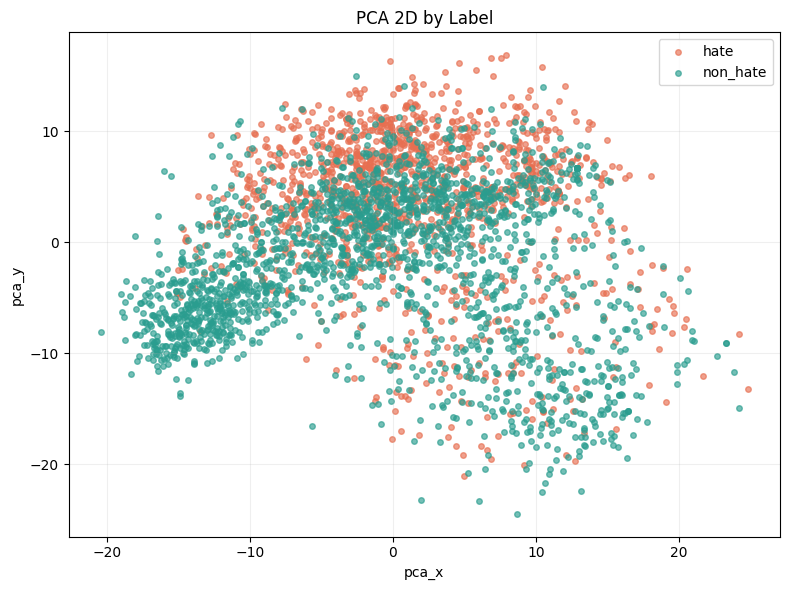

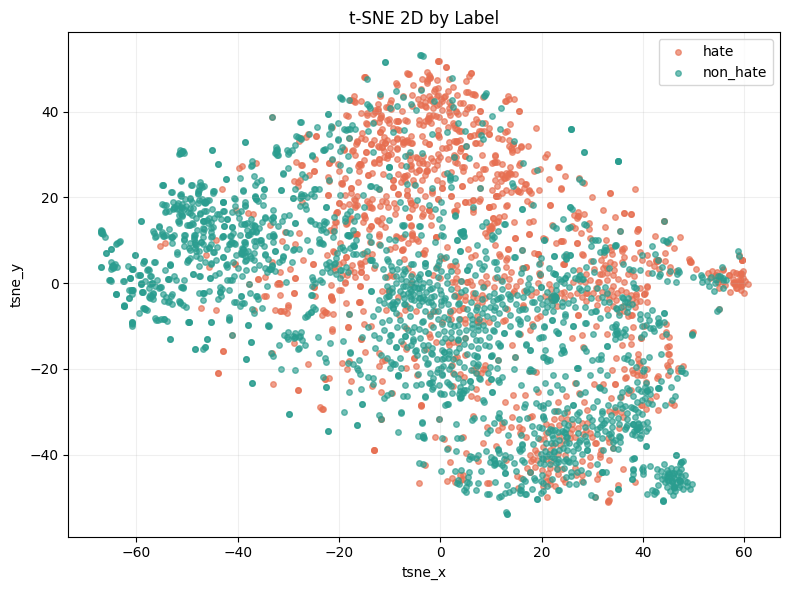

In [7]:
def plot_2d(df, x_col, y_col, title, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"non_hate": "#2a9d8f", "hate": "#e76f51"}
    for label_name, group in df.groupby("label_name"):
        ax.scatter(group[x_col], group[y_col], s=16, alpha=0.65, label=label_name, c=colors[label_name])
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(REPORT_DIR / filename, dpi=180)
    plt.show()


plot_2d(projection_df, "pca_x", "pca_y", "PCA 2D by Label", "projection_pca_2d_label.png")
plot_2d(projection_df, "tsne_x", "tsne_y", "t-SNE 2D by Label", "projection_tsne_2d_label.png")
if has_umap:
    plot_2d(projection_df, "umap_x", "umap_y", "UMAP 2D by Label", "projection_umap_2d_label.png")


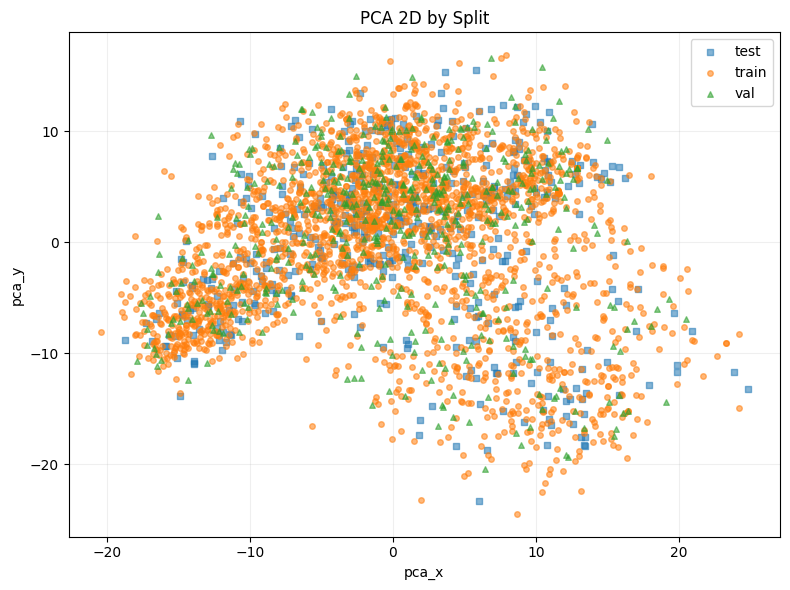

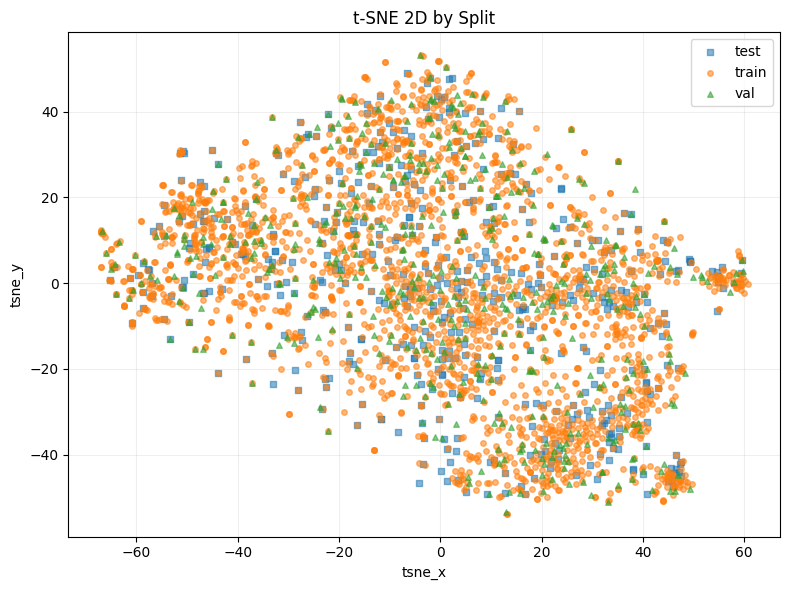

In [8]:
def plot_2d_by_split(df, x_col, y_col, title, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    markers = {"train": "o", "val": "^", "test": "s"}
    for split, group in df.groupby("split"):
        ax.scatter(group[x_col], group[y_col], s=16, alpha=0.55, label=split, marker=markers.get(split, "o"))
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(REPORT_DIR / filename, dpi=180)
    plt.show()


plot_2d_by_split(projection_df, "pca_x", "pca_y", "PCA 2D by Split", "projection_pca_2d_split.png")
plot_2d_by_split(projection_df, "tsne_x", "tsne_y", "t-SNE 2D by Split", "projection_tsne_2d_split.png")
if has_umap:
    plot_2d_by_split(projection_df, "umap_x", "umap_y", "UMAP 2D by Split", "projection_umap_2d_split.png")


## 3D Plot

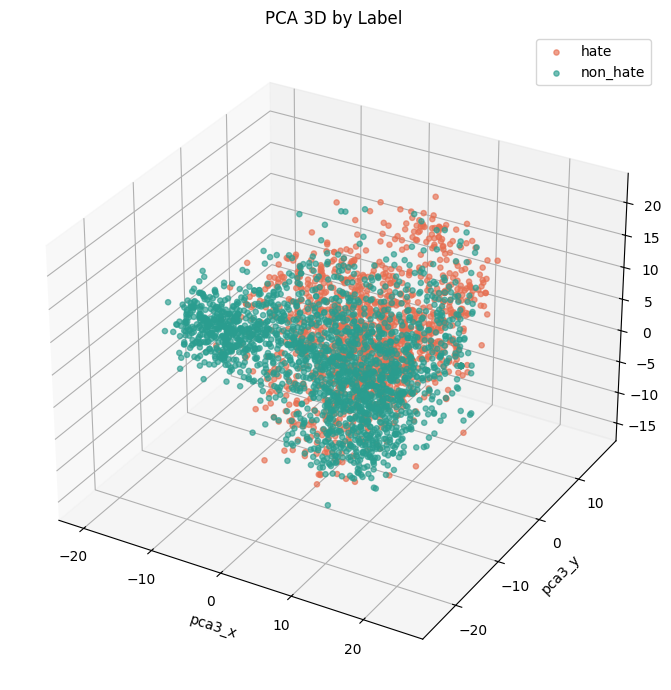

In [9]:
def plot_3d(df, x_col, y_col, z_col, title, filename):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    colors = {"non_hate": "#2a9d8f", "hate": "#e76f51"}
    for label_name, group in df.groupby("label_name"):
        ax.scatter(group[x_col], group[y_col], group[z_col], s=14, alpha=0.65, label=label_name, c=colors[label_name])
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    ax.legend()
    fig.tight_layout()
    fig.savefig(REPORT_DIR / filename, dpi=180)
    plt.show()


plot_3d(projection_df, "pca3_x", "pca3_y", "pca3_z", "PCA 3D by Label", "projection_pca_3d_label.png")
if has_umap:
    plot_3d(projection_df, "umap3_x", "umap3_y", "umap3_z", "UMAP 3D by Label", "projection_umap_3d_label.png")


## Outlier Inspection

In [10]:
def compute_centroid_outliers(df, x_col, y_col, top_k=25):
    rows = []
    for label_name, group in df.groupby("label_name"):
        center = group[[x_col, y_col]].to_numpy().mean(axis=0)
        distances = np.linalg.norm(group[[x_col, y_col]].to_numpy() - center[None, :], axis=1)
        tmp = group.copy()
        tmp["distance_from_label_centroid"] = distances
        rows.append(tmp.sort_values("distance_from_label_centroid", ascending=False).head(top_k))
    return pd.concat(rows, ignore_index=True)


outliers_df = compute_centroid_outliers(projection_df, "tsne_x", "tsne_y", top_k=25)
outliers_df.to_csv(REPORT_DIR / "dataset_projection_outliers.csv", index=False)
display(outliers_df[["source_video_id", "label_name", "split", "num_available_frames", "distance_from_label_centroid"]].head(50))


,source_video_id,label_name,split,num_available_frames,distance_from_label_centroid
0,BV1sb411X7b5,hate,val,1,63.605042
1,BV1xt4y1R7Kd,hate,train,1,63.449032
2,BV1q54y1u73X,hate,train,1,63.213711
3,R_hate_video_114,hate,train,64,62.732128
4,BV1dw411f76v,hate,train,2,61.907757
5,BV1bm4y1C75b,hate,train,1,61.887592
6,R_hate_video_138,hate,train,20,61.720119
7,BV1U94y1b7Q8,hate,train,20,61.565945
8,BV12V411N7ti,hate,val,1,60.920475
9,BV1wh411f7qV,hate,train,64,58.688137
